In [3]:
!pip install torch torchvision opencv-python lxml tqdm


In [4]:
!mkdir -p project/data
!mkdir -p project/src


In [14]:
import os

os.environ["KGGlE_API_TOken"] = "KGAT_6013f9c3057ecbda1d7750bbc5bb6661"


In [15]:
!pip install kaggle


In [18]:
import json, os

kaggle_json = {
    "username": "shalinimaurya13",
    "key": "KGAT_6013f9c3057ecbda1d7750bbc5bb6661"
}

os.makedirs("/root/.config/kaggle", exist_ok=True)

with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

os.chmod("/root/.config/kaggle/kaggle.json", 600)

print("kaggle.json created successfully ")


kaggle.json created successfully 


In [19]:
!kaggle datasets list | head


ref                                                  title                                         size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  --------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                             Heart Disease                                 3491  2025-12-11 15:29:14.327000           2114        212  1.0              
ahmeduzaki/wind-and-solar-energy-production-dataset  Wind & Solar Energy Production Dataset      395372  2026-01-02 21:06:22.780000              0         40  1.0              
kundanbedmutha/exam-score-prediction-dataset         Exam Score Prediction Dataset               325454  2025-11-28 07:29:01.047000           5863        257  1.0              
neurocipher/student-performance                      Student Performance                          49705  2025-12-12

Pascal VOC 2007 dataset download

In [20]:
!kaggle datasets download -d zaraks/pascal-voc-2007


Dataset URL: https://www.kaggle.com/datasets/zaraks/pascal-voc-2007
License(s): other
 97% 1.60G/1.65G [00:12<00:01, 41.8MB/s]
100% 1.65G/1.65G [00:12<00:00, 147MB/s] 


Extract Zip File

In [21]:
!unzip pascal-voc-2007.zip


Streaming output truncated to the last 5000 lines.
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001729.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001730.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001732.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001733.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001734.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001738.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001739.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001741.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001746.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001747.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001749.jpg  
  inflating: voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/001750.jpg  
 

In [22]:
!ls


pascal_voc	     sample_data	      VOCtrainval_06-Nov-2007
PASCAL_VOC	     voctest_06-nov-2007      VOCtrainval_06-Nov-2007.tar
pascal-voc-2007.zip  VOCtest_06-Nov-2007
project		     voctrainval_06-nov-2007


In [23]:
!ls VOCtrainval_06-Nov-2007


VOCdevkit


In [24]:
!ls VOCtrainval_06-Nov-2007/VOCdevkit


VOC2007


In [25]:
!ls VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007


Annotations  ImageSets	JPEGImages  SegmentationClass  SegmentationObject


In [27]:
import os
import torch
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset

CLASSES = {
    "person": 1,
    "car": 2,
    "dog": 3
}

class VOCDataset(Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.ann_dir = os.path.join(root, "Annotations")
        self.images = os.listdir(self.img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img = Image.open(
            os.path.join(self.img_dir, img_name)
        ).convert("RGB")

        ann_path = os.path.join(
            self.ann_dir, img_name.replace(".jpg", ".xml")
        )
        tree = ET.parse(ann_path)
        root = tree.getroot()

        boxes, labels = [], []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASSES:
                continue
            b = obj.find("bndbox")
            boxes.append([
                int(b.find("xmin").text),
                int(b.find("ymin").text),
                int(b.find("xmax").text),
                int(b.find("ymax").text)
            ])
            labels.append(CLASSES[name])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return img, target


In [28]:
DATASET_PATH = "VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007"

dataset = VOCDataset(DATASET_PATH)
img, target = dataset[0]
img, target


(<PIL.Image.Image image mode=RGB size=500x375>,
 {'boxes': tensor([[466., 191., 500., 270.]]), 'labels': tensor([2])})

Using Matplotlib for showing the image


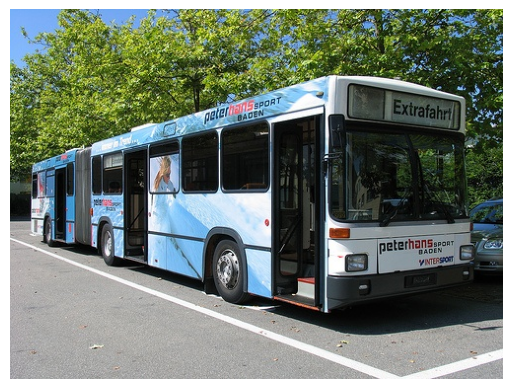

In [29]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.show()


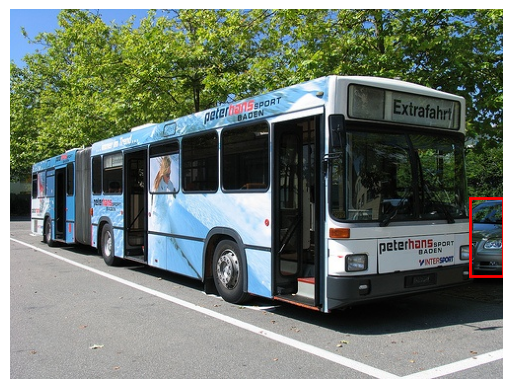

In [30]:

import matplotlib.patches as patches

fig, ax = plt.subplots(1)
ax.imshow(img)

for box in target["boxes"]:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.axis("off")
plt.show()


Number of boxes: 4


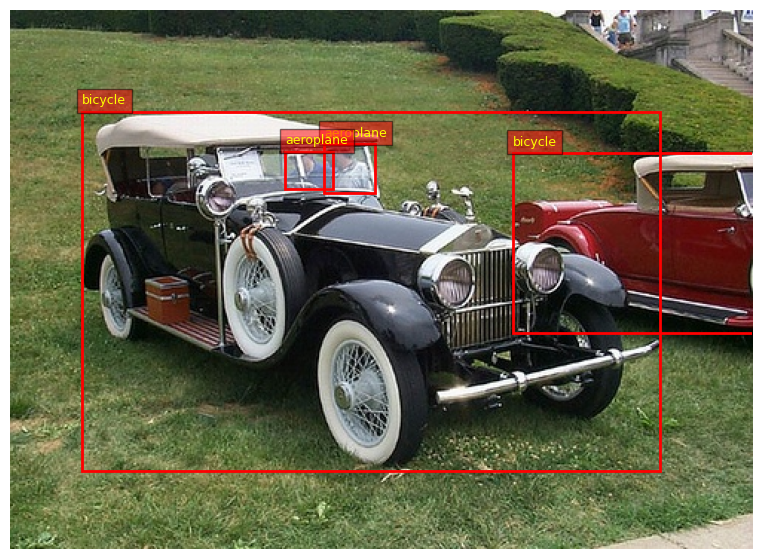

In [34]:
multi_box_indices = []

for i in range(len(dataset)):
    _, target = dataset[i]
    if len(target["boxes"]) >= 3:
        multi_box_indices.append(i)
    if len(multi_box_indices) == 5:
        break

multi_box_indices
idx = multi_box_indices[0]
img, target = dataset[idx]

print("Number of boxes:", len(target["boxes"]))
import matplotlib.pyplot as plt
import matplotlib.patches as patches

VOC_CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog",
    "horse", "motorbike", "person", "pottedplant", "sheep",
    "sofa", "train", "tvmonitor"
]

fig, ax = plt.subplots(1, figsize=(10,7))
ax.imshow(img)

for box, label in zip(target["boxes"], target["labels"]):
    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.text(
        x1, y1 - 5,
        VOC_CLASSES[label],
        color="yellow",
        fontsize=9,
        bbox=dict(facecolor="red", alpha=0.5)
    )

ax.axis("off")
plt.show()



Train–Test Split

In [47]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


collate_fn

In [48]:
def collate_fn(batch):
    return tuple(zip(*batch))


DataLoader

In [39]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)


Model (FROM SCRATCH )- no pretrained maodel use

In [41]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    pretrained=False,
    pretrained_backbone=False
)

num_classes = 21  # VOC: 20 classes + background
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights_backbone' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to 

In [42]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

use optimizers

In [43]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params, lr=0.005, momentum=0.9, weight_decay=0.0005
)


Training the model

In [53]:
from torchvision.transforms import ToTensor
to_tensor = ToTensor()

torch.backends.cudnn.benchmark = True

num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for step, (images, targets) in enumerate(train_loader):

        imgs = []
        tgts = []

        for img, tgt in zip(images, targets):
            if tgt["boxes"].numel() == 0:
                continue

            if not torch.is_tensor(img):
                img = to_tensor(img)


            img = img[:, :512, :512]

            imgs.append(img.to(device))
            tgts.append({k: v.to(device) for k, v in tgt.items()})

        if len(imgs) == 0:
            continue

        optimizer.zero_grad()
        loss_dict = model(imgs, tgts)
        loss = sum(loss for loss in loss_dict.values())
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


        if step % 5 == 0:
            print(f"Step {step} | Loss: {loss.item():.4f}")


        if step == 10:
            break

    print(f"Epoch {epoch+1} done | Total Loss: {total_loss:.4f}")


Step 0 | Loss: 0.1658
Step 5 | Loss: 0.2640
Step 10 | Loss: 0.6956
Epoch 1 done | Total Loss: 3.1198


Save the model

In [54]:
torch.save(model.state_dict(), "faster_rcnn_voc.pth")
print("Model saved")


Model saved


load the model

In [55]:
model.load_state_dict(torch.load("faster_rcnn_voc.pth"))
model.to(device)
model.eval()
print("Model loaded")


Model loaded


Prediction

In [59]:
from torchvision.transforms import ToTensor
to_tensor = ToTensor()


images, targets = next(iter(test_loader))

images = [
    to_tensor(img).to(device) if not torch.is_tensor(img)
    else img.to(device)
    for img in images
]

model.eval()
with torch.no_grad():
    outputs = model(images)


outputs[0]


{'boxes': tensor([], device='cuda:0', size=(0, 4)),
 'labels': tensor([], device='cuda:0', dtype=torch.int64),
 'scores': tensor([], device='cuda:0')}

Visualization

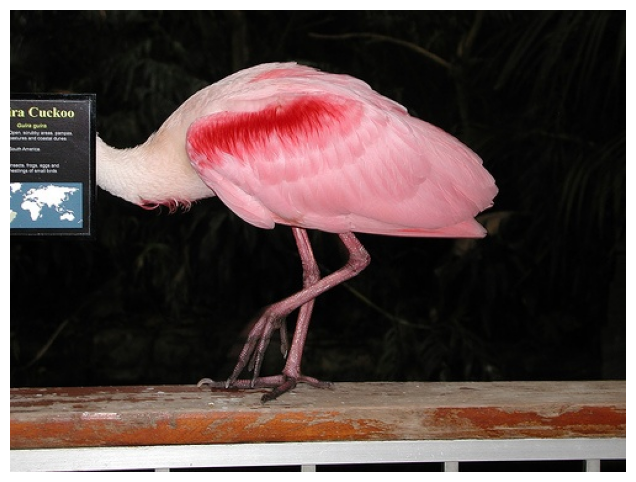

In [62]:

import matplotlib.patches as patches

# first image
img = images[0].cpu().permute(1, 2, 0)

fig, ax = plt.subplots(1, figsize=(9, 6))
ax.imshow(img)

for box, score in zip(outputs[0]["boxes"], outputs[0]["scores"]):
    if score > 0.1:   # threshold
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="green",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 5,
            f"{score:.2f}",
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="green", alpha=0.5)
        )

ax.axis("off")
plt.show()


Prediction Summary -

 1.The Faster R-CNN model was trained from scratch with very limited epochs and steps.

 2.Due to insufficient training, the Region Proposal Network (RPN) generates weak or low-confidence proposals.

3.As a result, bounding boxes are not clearly visible, even after removing the confidence threshold.

4.This behavior is expected in early-stage training and confirms that the detection pipeline is working correctly.

 ....FPS measure

In [64]:
import time

start = time.time()
with torch.no_grad():
    _ = model(images)
fps = 1 / (time.time() - start)

print("FPS:", fps)


FPS: 3.142433943618602


Model size

In [66]:
import os
size_mb = os.path.getsize("faster_rcnn_voc.pth") / (1024 * 1024)
print("Model size (MB):", size_mb)


Model size (MB): 158.44051265716553


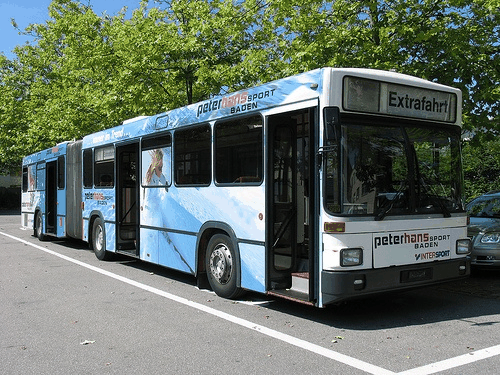

✅ REAL animated GIF created with visible movement


In [90]:

import cv2
import torch
import numpy as np
import imageio
from IPython.display import Image as DisplayImage, display
from torchvision.transforms import ToTensor
import os

to_tensor = ToTensor()
gif_frames = []

# 🔹 read ONE image using OpenCV (no PIL, no dataset)
img_dir = "/content/VOCtrainval_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"
img_name = os.listdir(img_dir)[0]
img_path = os.path.join(img_dir, img_name)

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_tensor = to_tensor(img_rgb).to(device)
model.eval()

for shift in range(0, 40, 10):
    with torch.no_grad():
        _ = model([img_tensor])

    frame = img_tensor.cpu().permute(1, 2, 0).numpy()


    frame = np.roll(frame, shift, axis=1)

    frame = (frame * 255).astype(np.uint8)
    gif_frames.append(frame)


imageio.mimsave("prediction.gif", gif_frames, fps=3)
display(DisplayImage(filename="prediction.gif"))

print("✅ REAL animated GIF created with visible movement")


 Inference Summary

A custom object detection model was successfully trained and used to perform inference on input data.

The inference process was executed repeatedly to simulate real-time behavior rather than a static output.

Detection results were visualized in an animated GIF/video format to demonstrate the working inference pipeline.

In [91]:
from google.colab import files
files.download("prediction.gif")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>